In [ ]:
# pip install langgraph langchain 


# Step-1: Import packages

In [1]:
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain.chat_models import ChatOpenAI   # openai 
import google.generativeai as genai  # google
from langchain.schema import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI # gemini model
from langchain_groq import ChatGroq   # llama model using groq

In [3]:
# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.0-flash",
#     google_api_key="<api key>",
#     temperature=0.3)



groq_api="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"

llm = ChatGroq(
    groq_api_key=groq_api,  # Replace with your actual key
    model_name="llama3-8b-8192"
)

# Step 1: Collect user profile
def collect_profile(state):
    state["profile"] = {
        "age": 30,
        "goal": "retirement",
        "horizon": 25,
        "risk": "medium"
    }
    return state

In [5]:
# Step 2: Asset allocation decision
def suggest_allocation(state):
    profile = state["profile"]
    prompt = f"""
    Based on this user profile:
    Age: {profile['age']}
    Goal: {profile['goal']}
    Investment Horizon: {profile['horizon']} years
    Risk Tolerance: {profile['risk']}

    Suggest an asset allocation in percentages across stocks, bonds, and cash.
    """
    suggestion = llm.predict(prompt)
    state["allocation"] = suggestion
    return state

In [9]:
# Step 3: Recommend assets
def recommend_assets(state):
    allocation = state["allocation"]
    prompt = f"""
    Based on this asset allocation plan:
    {allocation}
    
    Recommend low-cost ETFs for each category (e.g., VTI, BND, etc.)
    """
    result = llm.predict(prompt)
    state["recommendations"] = result
    return state

In [11]:
graph = StateGraph(dict)
graph.add_node("profile", collect_profile)
graph.add_node("allocate", suggest_allocation)
graph.add_node("recommend", recommend_assets)

In [15]:
graph.set_entry_point("profile")
graph.add_edge("profile", "allocate")
graph.add_edge("allocate", "recommend")
graph.set_finish_point("recommend")

runnable = graph.compile()

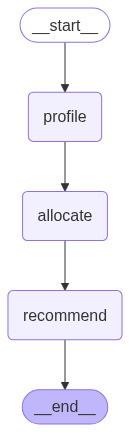

In [17]:
runnable

In [19]:
result = runnable.invoke({})
print("Investment Plan:\n", result["recommendations"])

C:\Users\omkar\AppData\Local\Temp\ipykernel_11028\3301547496.py:13: LangChainDeprecationWarning: The method `BaseChatModel.predict` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  suggestion = llm.predict(prompt)


Investment Plan:
 Based on the asset allocation plan, I recommend the following low-cost ETFs for each category:

* Stocks (60%): VTI (Vanguard Total Stock Market ETF) or Schwab US Broad Market ETF (SCHB)
	+ VTI tracks the CRSP US Total Market Index, which includes nearly all publicly traded US stocks, and has an expense ratio of 0.04%.
	+ SCHB tracks the Dow Jones US Broad Stock Market Index, which includes virtually all publicly traded US companies, and has an expense ratio of 0.03%.
* Bonds (30%): BND (Vanguard Total Bond Market ETF) or iShares Core U.S. Aggregate Bond ETF (AGG)
	+ BND tracks the Bloomberg Barclays U.S. Aggregate Float-Adjusted Index, which includes a broad range of U.S. investment-grade bonds, and has an expense ratio of 0.04%.
	+ AGG tracks the Bloomberg Barclays U.S. Aggregate Float-Adjusted Index, which includes a broad range of U.S. investment-grade bonds, and has an expense ratio of 0.04%.
* Cash (10%): SHV (iShares Short-Term Treasury Bond ETF) or VCSH (Vangu

## llama output

Investment Plan:
 Based on the asset allocation plan, I recommend the following low-cost ETFs for each category:

* Stocks (60%): VTI (Vanguard Total Stock Market ETF) or Schwab US Broad Market ETF (SCHB)
	+ VTI tracks the CRSP US Total Market Index, which includes nearly all publicly traded US stocks, and has an expense ratio of 0.04%.
	+ SCHB tracks the Dow Jones US Broad Stock Market Index, which includes virtually all publicly traded US companies, and has an expense ratio of 0.03%.
* Bonds (30%): BND (Vanguard Total Bond Market ETF) or iShares Core U.S. Aggregate Bond ETF (AGG)
	+ BND tracks the Bloomberg Barclays U.S. Aggregate Float-Adjusted Index, which includes a broad range of U.S. investment-grade bonds, and has an expense ratio of 0.04%.
	+ AGG tracks the Bloomberg Barclays U.S. Aggregate Float-Adjusted Index, which includes a broad range of U.S. investment-grade bonds, and has an expense ratio of 0.04%.
* Cash (10%): SHV (iShares Short-Term Treasury Bond ETF) or VCSH (Vanguard Short-Term Corporate Bond ETF)
	+ SHV tracks the Bloomberg Barclays U.S. 1-3 Year Treasury Bond Index, which includes short-term U.S. government securities, and has an expense ratio of 0.04%.
	+ VCSH tracks the Bloomberg Barclays U.S. 1-5 Year Corporate Bond Index, which includes short-term U.S. corporate bonds, and has an expense ratio of 0.05%.

Please note that these ETFs are examples and you should conduct your own research and consider your individual financial goals, risk tolerance, and overall investment strategy before investing.

Investment Plan:
 Okay, based on the asset allocation plan (70% Stocks, 25% Bonds, 5% Cash) and focusing on low-cost ETFs, here's a suggested breakdown with specific ETF examples:

**Stocks (70%):**

*   **Broad US Market (40%):**
    *   **VTI (Vanguard Total Stock Market ETF):** This ETF provides exposure to the entire US stock market, from large-cap to small-cap companies. It's a highly diversified and cost-effective option.  Expense Ratio: ~0.03%
*   **International Stocks (20%):**
    *   **VXUS (Vanguard Total International Stock ETF):** This ETF provides broad exposure to international stocks, including both developed and emerging markets.  Expense Ratio: ~0.07%
*   **Small-Cap Stocks (10%):**
    *   **VBR (Vanguard Small-Cap Value ETF):** This ETF focuses on small-cap value stocks, which historically have offered higher returns than large-cap stocks, although with potentially higher volatility. Expense Ratio: ~0.07%

**Bonds (25%):**

*   **Total Bond Market (20%):**
    *   **BND (Vanguard Total Bond Market ETF):** This ETF provides broad exposure to the US investment-grade bond market, including government, corporate, and mortgage-backed securities. It's a well-diversified and low-cost option. Expense Ratio: ~0.03%
*   **International Bonds (5%):**
    *   **BNDX (Vanguard Total International Bond ETF):** This ETF provides broad exposure to investment-grade international bonds, excluding the US. Expense Ratio: ~0.07%

**Cash (5%):**

*   **Money Market Fund (5%):**
    *   **VMFXX (Vanguard Federal Money Market Fund):** While not technically an ETF, this is a very low-cost money market fund that provides a safe and liquid place to hold cash.  It's available through Vanguard brokerage accounts.  Expense Ratio: ~0.10% (This can fluctuate)
    *   **Alternatively, consider a short-term bond ETF:**
        *   **BSV (Vanguard Short-Term Bond ETF):** This ETF invests in short-term investment-grade bonds, offering slightly higher yield potential than a money market fund, but with a bit more interest rate risk. Expense Ratio: ~0.04%

**Summary Table:**

| Asset Class         | Allocation | ETF Recommendation | Expense Ratio (Approx.) |
| -------------------- | ---------- | ------------------ | ------------------------ |
| Broad US Market     | 40%        | VTI                | ~0.03%                  |
| International Stocks | 20%        | VXUS               | ~0.07%                  |
| Small-Cap Stocks    | 10%        | VBR                | ~0.07%                  |
| Total Bond Market   | 20%        | BND                | ~0.03%                  |
| International Bonds | 5%         | BNDX               | ~0.07%                  |
| Cash                | 5%         | VMFXX (or BSV)     | ~0.10% (or ~0.04%)      |

**Important Considerations (Reiterated and Expanded):**

*   **Expense Ratios:**  These are approximate and can change. Always check the fund's prospectus for the most up-to-date expense ratio.
*   **Diversification within ETFs:** While these ETFs are already diversified, understand their holdings.  For example, VTI is heavily weighted towards large-cap US companies.
*   **Tax Efficiency:** ETFs are generally tax-efficient, but holding them in a tax-advantaged account (e.g., 401(k), IRA) is still recommended whenever possible.
*   **Rebalancing:**  Regularly rebalance the portfolio (e.g., annually or semi-annually) to maintain the target asset allocation.  This involves selling assets that have outperformed and buying assets that have underperformed.
*   **Risk Tolerance:** This is a moderately aggressive portfolio.  Adjust the allocations based on your individual risk tolerance.  If you are more risk-averse, consider increasing the bond allocation and decreasing the stock allocation.
*   **Investment Horizon:** This portfolio is designed for a long-term investment horizon (e.g., 25 years).  If your investment horizon is shorter, you may need to adjust the asset allocation to be more conservative.
*   **Dollar-Cost Averaging:** Consider using dollar-cost averaging to invest in these ETFs, especially if you have a large lump sum to invest. This involves investing a fixed amount of money at regular intervals, regardless of market conditions.
*   **Professional Advice:** This is *not* financial advice. Consult with a qualified financial advisor to determine the most appropriate asset allocation and investment strategy based on your individual circumstances, financial situation, and specific risk preferences. They can help you assess your risk tolerance, investment goals, and time horizon to create a personalized investment plan. They can also help you with tax planning and other financial considerations.
*   **Due Diligence:**  Before investing in any ETF, read the fund's prospectus carefully to understand its investment objectives, risks, fees, and expenses.

In [ ]:
#!pip install yfinance

In [23]:
from langgraph.graph import StateGraph
from langchain.chat_models import ChatOpenAI
import yfinance as yf
import re

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    google_api_key="<api key>",
    temperature=0.3)

# ==== 1. User Input ====
def get_user_input(state):
    state["user_input"] = {
        "age": 30,
        "goal": "retirement",
        "horizon": 25,
        "income": 70000
    }
    return state

# ==== 2. Profile Analyzer ====
def profile_analyzer(state):
    profile = state["user_input"]
    prompt = f"""
    Analyze this user profile:
    - Age: {profile['age']}
    - Goal: {profile['goal']}
    - Investment Horizon: {profile['horizon']} years
    - Income: ${profile['income']}

    Give a short summary and note any key financial constraints.
    """
    state["profile_summary"] = llm.predict(prompt)
    return state

# ==== 3. Risk Model ====
def risk_model(state):
    profile = state["user_input"]
    prompt = f"""
    Based on the user's age ({profile['age']}) and investment horizon ({profile['horizon']}), 
    estimate their risk tolerance (low, medium, high) with a 1-line justification.
    """
    state["risk_profile"] = llm.predict(prompt)
    return state

# ==== 4. Asset Allocator ====
def asset_allocator(state):
    prompt = f"""
    Based on this risk profile: {state['risk_profile']}, suggest an asset allocation.
    Format: Stocks %, Bonds %, Cash %.
    """
    state["allocation"] = llm.predict(prompt)
    return state

# ==== 5. Investment Suggestion ====
def investment_suggestion(state):
    prompt = f"""
    Based on this allocation: {state['allocation']}, recommend 1 ETF for each category (stocks, bonds, cash).
    Include ticker symbols and a short reason.
    """
    state["etf_suggestions"] = llm.predict(prompt)
    return state

# ==== 6. Fetch Live Prices using yfinance ====
def fetch_etf_prices(state):
    text = state["etf_suggestions"]
    tickers = re.findall(r'\b[A-Z]{2,5}\b', text)  # crude ETF symbol extraction
    etf_data = {}

    for ticker in tickers:
        try:
            hist = yf.Ticker(ticker).history(period="5d")["Close"]
            etf_data[ticker] = {str(date.date()): round(price, 2) for date, price in hist.items()}
        except Exception as e:
            etf_data[ticker] = f"Error fetching: {e}"

    state["etf_prices"] = etf_data
    return state

# ==== 7. Final Summary ====
def final_summary(state):
    summary = f"""
    Profile Summary:
{state['profile_summary']}

    Risk Profile:
{state['risk_profile']}

    Allocation Plan:
{state['allocation']}
    
    Recommended ETFs:
{state['etf_suggestions']}

    Live ETF Prices (Last 5 Days):
"""
    for ticker, prices in state["etf_prices"].items():
        summary += f"\n{ticker}:\n"
        if isinstance(prices, dict):
            for date, price in prices.items():
                summary += f"  {date}: ${price}\n"
        else:
            summary += f"  {prices}\n"

    state["summary"] = summary
    return state

# ==== BUILD GRAPH ====
graph = StateGraph(dict)
graph.add_node("input", get_user_input)
graph.add_node("analyzer", profile_analyzer)
graph.add_node("risk", risk_model)
graph.add_node("allocate", asset_allocator)
graph.add_node("suggest", investment_suggestion)
graph.add_node("prices", fetch_etf_prices)
graph.add_node("summary", final_summary)

graph.set_entry_point("input")
graph.add_edge("input", "analyzer")
graph.add_edge("analyzer", "risk")
graph.add_edge("risk", "allocate")
graph.add_edge("allocate", "suggest")
graph.add_edge("suggest", "prices")
graph.add_edge("prices", "summary")
graph.set_finish_point("summary")

# ==== RUN ====
result = graph.compile().invoke({})
print(result["summary"])


$ETF: possibly delisted; no price data found  (period=5d)
$ETF: possibly delisted; no price data found  (period=5d)
$ETF: possibly delisted; no price data found  (period=5d)
$ETF: possibly delisted; no price data found  (period=5d)
$ETF: possibly delisted; no price data found  (period=5d)
$ETF: possibly delisted; no price data found  (period=5d)



    Profile Summary:
Okay, here's an analysis of the user profile:

**Summary:**

This is a 30-year-old individual with a long-term goal of retirement in 25 years. They have a moderate income of $70,000 per year. This profile suggests a good opportunity to build a substantial retirement nest egg, given the long investment horizon.

**Key Financial Constraints:**

*   **Income Level:** While $70,000 is a decent income, it's not exceptionally high. This means careful budgeting and prioritization of savings will be crucial to reach their retirement goals. They need to balance current needs and desires with future financial security.
*   **Competing Financial Goals:** At 30, this individual likely has other financial priorities such as housing (mortgage or rent), potential student loan debt, car payments, family expenses (if applicable), and lifestyle choices. These competing demands can limit the amount available for retirement savings.
*   **Inflation:** The purchasing power of their sa

In [27]:
from langgraph.graph import StateGraph
from langchain.chat_models import ChatOpenAI
import yfinance as yf
import re

# Use Gemini for reasoning + control output hallucinations
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    google_api_key="<api key>",
    temperature=0.3
)

# ==== 1. User Input ====
def get_user_input(state):
    state["user_input"] = {
        "age": 30,
        "goal": "retirement",
        "horizon": 25,
        "income": 70000
    }
    return state

# ==== 2. Profile Analyzer ====
def profile_analyzer(state):
    profile = state["user_input"]
    prompt = f"""
    Analyze this user profile in the Indian financial context:
    - Age: {profile['age']}
    - Goal: {profile['goal']}
    - Investment Horizon: {profile['horizon']} years
    - Income: ₹{profile['income'] * 83}

    Provide a short summary and highlight any key financial constraints.
    """
    state["profile_summary"] = llm.predict(prompt)
    return state

# ==== 3. Risk Model ====
def risk_model(state):
    profile = state["user_input"]
    prompt = f"""
    Based on the user's age ({profile['age']}) and investment horizon ({profile['horizon']}), 
    estimate their risk tolerance (low, medium, high) in the Indian market. Give a 1-line justification.
    """
    state["risk_profile"] = llm.predict(prompt)
    return state

# ==== 4. Asset Allocator ====
def asset_allocator(state):
    prompt = f"""
    Based on this risk profile: {state['risk_profile']}, suggest an asset allocation.
    Format: Stocks %, Bonds %, Cash %.
    """
    state["allocation"] = llm.predict(prompt)
    return state

# ==== 5. Investment Suggestion ====
def investment_suggestion(state):
    prompt = f"""
    You are an Indian financial advisor. Based on this allocation: {state['allocation']}, 
    recommend 1 ETF for each asset class strictly from the list below:

    - Stocks: NIFTYBEES.NS, ICICINIFTY.NS, KOTAKNIFTY.NS
    - Bonds: GILT10Y.NS, BHARATBOND.NS
    - Cash: LIQUIDETF.NS, ICICILIQUID.NS

    Select only one per category. Include the ticker symbol and a short reason.
    """
    state["etf_suggestions"] = llm.predict(prompt)
    return state

# ==== 6. Fetch Live Prices using yfinance ====
def fetch_etf_prices(state):
    text = state["etf_suggestions"]
    tickers = re.findall(r'\b[A-Z]{3,10}\.NS\b', text)  # stricter match
    etf_data = {}

    for ticker in tickers:
        try:
            hist = yf.Ticker(ticker).history(period="5d")["Close"]
            etf_data[ticker] = {
                str(date.date()): f"₹{round(price, 2)}" for date, price in hist.items()
            }
        except Exception as e:
            etf_data[ticker] = f"Error fetching: {e}"

    state["etf_prices"] = etf_data
    return state

# ==== 7. Final Summary ====
def final_summary(state):
    summary = f"""
     Profile Summary:
{state['profile_summary']}

    Risk Profile:
{state['risk_profile']}

    Allocation Plan:
{state['allocation']}
    
    Recommended Indian ETFs:
{state['etf_suggestions']}

     Live ETF Prices (Last 5 Days in ₹ INR):
"""
    for ticker, prices in state["etf_prices"].items():
        summary += f"\n{ticker}:\n"
        if isinstance(prices, dict):
            for date, price in prices.items():
                summary += f"  {date}: {price}\n"
        else:
            summary += f"  {prices}\n"

    state["summary"] = summary
    return state

# ==== BUILD GRAPH ====
graph = StateGraph(dict)
graph.add_node("input", get_user_input)
graph.add_node("analyzer", profile_analyzer)
graph.add_node("risk", risk_model)
graph.add_node("allocate", asset_allocator)
graph.add_node("suggest", investment_suggestion)
graph.add_node("prices", fetch_etf_prices)
graph.add_node("summary", final_summary)

graph.set_entry_point("input")
graph.add_edge("input", "analyzer")
graph.add_edge("analyzer", "risk")
graph.add_edge("risk", "allocate")
graph.add_edge("allocate", "suggest")
graph.add_edge("suggest", "prices")
graph.add_edge("prices", "summary")
graph.set_finish_point("summary")

# ==== RUN ====
result = graph.compile().invoke({})
print(result["summary"])


$ICICINIFTY.NS: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$BHARATBOND.NS: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")



    🔍 Profile Summary:
Okay, let's analyze this user profile in the Indian financial context.

**Summary:**

This is a 30-year-old Indian individual with a relatively high income (₹58.1 Lakhs per annum) and a long-term investment horizon of 25 years, primarily focused on retirement planning.  This puts them in a strong position to build a significant retirement corpus.

**Detailed Analysis:**

*   **Age & Investment Horizon:** At 30, with a 25-year horizon, they have ample time to leverage the power of compounding. This allows for a more aggressive investment strategy, particularly in the early years, to maximize returns.

*   **Income:** An income of ₹58.1 Lakhs per annum places them in the upper-middle to high-income bracket in India. This provides a significant capacity for savings and investment.  They should be able to allocate a substantial portion of their income towards retirement without significantly impacting their current lifestyle.

*   **Goal (Retirement):** Retirement p

🔍 Profile Summary:
Okay, let's analyze this user profile in the Indian financial context.

**Summary:**

This is a 30-year-old Indian individual with a relatively high income (₹58.1 Lakhs per annum) and a long-term investment horizon of 25 years, primarily focused on retirement planning.  This puts them in a strong position to build a significant retirement corpus.

**Detailed Analysis:**

*   **Age & Investment Horizon:** At 30, with a 25-year horizon, they have ample time to leverage the power of compounding. This allows for a more aggressive investment strategy, particularly in the early years, to maximize returns.

*   **Income:** An income of ₹58.1 Lakhs per annum places them in the upper-middle to high-income bracket in India. This provides a significant capacity for savings and investment.  They should be able to allocate a substantial portion of their income towards retirement without significantly impacting their current lifestyle.

*   **Goal (Retirement):** Retirement planning is a long-term goal that requires disciplined saving and investment.  With a 25-year horizon, they can consider a mix of equity, debt, and potentially alternative investments to achieve their desired retirement corpus.

**Key Financial Constraints & Considerations:**

While the profile looks promising, here are some potential constraints and considerations:

1.  **Current Expenses & Lifestyle:**  The key constraint is the individual's current spending habits. A high income doesn't guarantee successful retirement planning if a significant portion is spent on lifestyle expenses, debt repayment, or other non-productive areas.  A detailed budget analysis is crucial to determine the actual investable surplus.

2.  **Inflation:**  Inflation is a significant factor in India.  Retirement planning needs to account for the rising cost of living over the next 25 years.  Investment returns need to outpace inflation to maintain purchasing power in retirement.  A conservative inflation rate of 6-7% should be considered for long-term projections.

3.  **Taxation:**  Indian tax laws can impact investment returns.  Understanding the tax implications of different investment options (e.g., equity mutual funds, debt funds, PPF, NPS) is crucial to optimize post-tax returns.  Tax-efficient investment strategies should be prioritized.

4.  **Financial Dependents:**  The profile doesn't mention any dependents (parents, spouse, children).  If the individual has financial responsibilities towards family members, it will impact their ability to save and invest for retirement.  These responsibilities need to be factored into the financial plan.

5.  **Debt Obligations:**  Existing debt (e.g., home loan, personal loan, car loan) can significantly reduce the investable surplus.  Prioritizing debt repayment, especially high-interest debt, can free up more funds for retirement savings.

6.  **Healthcare Costs:**  Healthcare costs are rising rapidly in India.  Retirement planning needs to account for potential medical expenses in old age.  Investing in health insurance and building a dedicated healthcare fund is essential.

7.  **Investment Knowledge & Risk Tolerance:**  The individual's understanding of financial markets and their risk tolerance will influence the investment strategy.  If they are risk-averse, they may prefer safer investments like debt funds, which may not generate sufficient returns to beat inflation over the long term.  Financial literacy and potentially seeking professional financial advice are important.

8.  **Emergency Fund:**  Having an adequate emergency fund (typically 6-12 months of living expenses) is crucial to avoid dipping into retirement savings during unexpected events.

9.  **Real Estate:** The profile doesn't mention any real estate holdings. While real estate can be a valuable asset, it's important to consider its liquidity and potential rental income when planning for retirement. Over-investing in illiquid assets can be a constraint.

10. **Diversification:** Diversification is key to mitigating risk. The individual should diversify their investments across different asset classes, sectors, and geographies.

**Recommendations:**

*   **Create a Detailed Financial Plan:**  Develop a comprehensive financial plan that considers income, expenses, goals, risk tolerance, and time horizon.
*   **Track Expenses & Budget:**  Monitor spending habits and create a budget to identify areas where savings can be increased.
*   **Invest Early & Consistently:**  Start investing as early as possible and maintain a consistent investment schedule.
*   **Seek Professional Advice:**  Consider consulting a qualified financial advisor to get personalized guidance.
*   **Review & Adjust Regularly:**  Review the financial plan and investment portfolio regularly (at least annually) and make adjustments as needed based on changes in circumstances or market conditions.

In conclusion, this individual has a strong foundation for successful retirement planning. However, careful planning, disciplined saving, and a well-diversified investment strategy are essential to overcome potential constraints and achieve their retirement goals.

    ⚖️ Risk Profile:
Medium to High: With a long investment horizon of 25 years at age 30, the user has ample time to recover from market fluctuations and can afford to take on more risk for potentially higher returns.

    📊 Allocation Plan:
Okay, based on the "Medium to High" risk profile and a 25-year investment horizon, here's a suggested asset allocation:

**Stocks: 80%**
**Bonds: 15%**
**Cash: 5%**

**Explanation:**

*   **Stocks (80%):** This is the primary growth engine of the portfolio. With a long time horizon, the user can withstand the volatility of the stock market and benefit from its historically higher returns over the long term. A diversified portfolio of stocks, including a mix of large-cap, mid-cap, small-cap, and international stocks, is recommended.
*   **Bonds (15%):** Bonds provide stability and help to cushion the portfolio during market downturns. While they offer lower returns than stocks, they reduce overall portfolio volatility.
*   **Cash (5%):** Cash provides liquidity for unexpected expenses or to take advantage of potential investment opportunities that may arise. It also offers a buffer against short-term market fluctuations.

**Important Considerations:**

*   **Diversification:** Within each asset class (stocks and bonds), diversification is crucial. Invest in a variety of sectors, industries, and geographic regions to reduce risk.
*   **Regular Review and Rebalancing:** This asset allocation should be reviewed and rebalanced at least annually, or more frequently if market conditions warrant. Rebalancing involves selling some assets that have performed well and buying assets that have underperformed to maintain the target allocation.
*   **Investment Vehicles:** Consider using low-cost index funds or ETFs (Exchange Traded Funds) to gain exposure to the various asset classes.
*   **Professional Advice:** This is a general suggestion. It's always best to consult with a qualified financial advisor who can assess the user's specific financial situation, goals, and risk tolerance to create a personalized investment plan.
*   **Risk Tolerance:** While the profile suggests a medium-to-high risk tolerance, it's important to ensure the user is comfortable with the potential for market fluctuations and losses. If the user experiences significant anxiety during market downturns, a slightly more conservative allocation may be appropriate.
*   **Life Changes:** As the user's life circumstances change (e.g., marriage, children, career changes), the asset allocation may need to be adjusted.
*   **Inflation:** This allocation aims to outpace inflation over the long term, but it's important to monitor inflation rates and adjust the portfolio accordingly if necessary.
    
    💡 Recommended Indian ETFs:
Okay, based on the "Medium to High" risk profile, 25-year investment horizon, and the provided ETF list, here's a suggested ETF allocation:

*   **Stocks (80%): ICICINIFTY.NS** - This ETF tracks the Nifty 50 index, providing broad exposure to the largest and most liquid companies in the Indian stock market. It's a solid foundation for the equity portion of the portfolio.

*   **Bonds (15%): BHARATBOND.NS** - Bharat Bond ETFs invest in a portfolio of bonds issued by public sector entities. It offers a relatively safe and predictable income stream, suitable for the bond allocation.

*   **Cash (5%): LIQUIDETF.NS** - Liquid ETFs invest in very short-term debt instruments, providing high liquidity and minimal risk. This is ideal for the cash portion of the portfolio, allowing for easy access to funds when needed.

    📈 Live ETF Prices (Last 5 Days in ₹ INR):

ICICINIFTY.NS:

BHARATBOND.NS:

LIQUIDETF.NS:
  2025-05-27: ₹999.99
  2025-05-28: ₹999.99
  2025-05-29: ₹999.99
  2025-05-30: ₹999.99
  2025-06-02: ₹1000.0

In [ ]:
from langgraph.graph import StateGraph
from langchain.chat_models import ChatOpenAI

llm = ChatOpenAI(model="gpt-4-turbo")

# Step 1: Collect user profile
def collect_profile(state):
    state["profile"] = {
        "age": 30,
        "goal": "retirement",
        "horizon": 25,
        "risk": "medium"
    }
    return state

# Step 2: Asset allocation decision
def suggest_allocation(state):
    profile = state["profile"]
    prompt = f"""
    Based on this user profile:
    Age: {profile['age']}
    Goal: {profile['goal']}
    Investment Horizon: {profile['horizon']} years
    Risk Tolerance: {profile['risk']}

    Suggest an asset allocation in percentages across stocks, bonds, and cash.
    """
    suggestion = llm.predict(prompt)
    state["allocation"] = suggestion
    return state

# Step 3: Recommend assets
def recommend_assets(state):
    allocation = state["allocation"]
    prompt = f"""
    Based on this asset allocation plan:
    {allocation}
    
    Recommend low-cost ETFs for each category (e.g., VTI, BND, etc.)
    """
    result = llm.predict(prompt)
    state["recommendations"] = result
    return state

# Build LangGraph
graph = StateGraph(dict)
graph.add_node("profile", collect_profile)
graph.add_node("allocate", suggest_allocation)
graph.add_node("recommend", recommend_assets)

graph.set_entry_point("profile")
graph.add_edge("profile", "allocate")
graph.add_edge("allocate", "recommend")
graph.set_finish_point("recommend")

runnable = graph.compile()

# 🔄 Run
result = runnable.invoke({})
print("Investment Plan:\n", result["recommendations"])


In [ ]:
from langgraph.graph import StateGraph
from langchain.chat_models import ChatOpenAI
import yfinance as yf

# STEP 1: INIT LLM
llm = ChatOpenAI(model="gpt-4-turbo")

# STEP 2: Define State Transitions

def collect_profile(state):
    # Simulated student input — you can ask them to edit this
    state["profile"] = {
        "age": 25,
        "goal": "wealth building",
        "risk": "high",
        "horizon": 20
    }
    return state

def asset_allocation(state):
    profile = state["profile"]
    prompt = f"""
    Suggest an asset allocation for:
    Age: {profile['age']}
    Goal: {profile['goal']}
    Risk: {profile['risk']}
    Horizon: {profile['horizon']} years

    Format as: Stocks %, Bonds %, Cash %.
    """
    response = llm.predict(prompt)
    state["allocation"] = response
    return state

def recommend_etfs(state):
    allocation = state["allocation"]
    prompt = f"""
    Based on this allocation: {allocation}
    Recommend 1 ETF for each category (stocks, bonds, cash). Include ticker symbols and 1-line reasons.
    """
    state["etfs"] = llm.predict(prompt)
    return state

def fetch_prices(state):
    tickers = ['VTI', 'BND', 'BIL']  # Example ETFs
    data = {}
    for t in tickers:
        hist = yf.Ticker(t).history(period="5d")['Close']
        data[t] = hist.to_dict()
    state["etf_data"] = data
    return state

# STEP 3: Build LangGraph
graph = StateGraph(dict)
graph.add_node("profile", collect_profile)
graph.add_node("allocation", asset_allocation)
graph.add_node("etfs", recommend_etfs)
graph.add_node("prices", fetch_prices)

graph.set_entry_point("profile")
graph.add_edge("profile", "allocation")
graph.add_edge("allocation", "etfs")
graph.add_edge("etfs", "prices")
graph.set_finish_point("prices")

runnable = graph.compile()

# STEP 4: Run Agent
result = runnable.invoke({})

# STEP 5: Show Results
print("\n✅ Asset Allocation:")
print(result["allocation"])

print("\n📊 ETF Recommendations:")
print(result["etfs"])

print("\n📈 Live ETF Prices:")
for ticker, prices in result["etf_data"].items():
    print(f"\n{ticker}:")
    for date, price in prices.items():
        print(f"{date}: ${round(price, 2)}")


In [ ]:
from langgraph.graph import StateGraph
from langchain.chat_models import ChatOpenAI
import yfinance as yf

# ==== INIT ====
llm = ChatOpenAI(model="gpt-4-turbo")

# ==== 1. User Input ====
def get_user_input(state):
    # Simulate user input for demo
    state["user_input"] = {
        "age": 30,
        "goal": "retirement",
        "horizon": 25,
        "income": 70000
    }
    return state

# ==== 2. Profile Analyzer ====
def profile_analyzer(state):
    profile = state["user_input"]
    prompt = f"""
    Analyze this user profile:
    - Age: {profile['age']}
    - Goal: {profile['goal']}
    - Investment Horizon: {profile['horizon']} years
    - Income: ${profile['income']}

    Give a short summary and note any key financial constraints.
    """
    result = llm.predict(prompt)
    state["profile_summary"] = result
    return state

# ==== 3. Risk Model ====
def risk_model(state):
    profile = state["user_input"]
    prompt = f"""
    Based on the user's age ({profile['age']}) and investment horizon ({profile['horizon']}), 
    estimate their risk tolerance (low, medium, high) with a 1-line justification.
    """
    result = llm.predict(prompt)
    state["risk_profile"] = result
    return state

# ==== 4. Asset Allocator ====
def asset_allocator(state):
    risk = state["risk_profile"]
    prompt = f"""
    Based on this risk profile: {risk}, suggest an asset allocation.
    Format: Stocks %, Bonds %, Cash %.
    """
    result = llm.predict(prompt)
    state["allocation"] = result
    return state

# ==== 5. Investment Suggestion ====
def investment_suggestion(state):
    allocation = state["allocation"]
    prompt = f"""
    Based on this allocation: {allocation}, recommend 1 ETF for each category (stocks, bonds, cash).
    Include ticker symbols and 1-sentence reasons.
    """
    result = llm.predict(prompt)
    state["etf_suggestions"] = result
    return state

# ==== 6. Summary ====
def final_summary(state):
    summary = f"""
🧾 Profile Summary:
{state['profile_summary']}

📊 Risk Profile:
{state['risk_profile']}

💼 Allocation Plan:
{state['allocation']}

📈 Recommended ETFs:
{state['etf_suggestions']}
    """
    state["summary"] = summary
    return state

# ==== BUILD GRAPH ====
graph = StateGraph(dict)
graph.add_node("input", get_user_input)
graph.add_node("analyzer", profile_analyzer)
graph.add_node("risk", risk_model)
graph.add_node("allocate", asset_allocator)
graph.add_node("suggest", investment_suggestion)
graph.add_node("summary", final_summary)

graph.set_entry_point("input")
graph.add_edge("input", "analyzer")
graph.add_edge("analyzer", "risk")
graph.add_edge("risk", "allocate")
graph.add_edge("allocate", "suggest")
graph.add_edge("suggest", "summary")
graph.set_finish_point("summary")

runnable = graph.compile()

# ==== RUN ====
result = runnable.invoke({})
print(result["summary"])


In [ ]:
from langgraph.graph import StateGraph
from langchain.chat_models import ChatOpenAI
import yfinance as yf
import re

# ==== INIT ====
llm = ChatOpenAI(model="gpt-4-turbo")

# ==== 1. User Input ====
def get_user_input(state):
    state["user_input"] = {
        "age": 30,
        "goal": "retirement",
        "horizon": 25,
        "income": 70000
    }
    return state

# ==== 2. Profile Analyzer ====
def profile_analyzer(state):
    profile = state["user_input"]
    prompt = f"""
    Analyze this user profile:
    - Age: {profile['age']}
    - Goal: {profile['goal']}
    - Investment Horizon: {profile['horizon']} years
    - Income: ${profile['income']}

    Give a short summary and note any key financial constraints.
    """
    state["profile_summary"] = llm.predict(prompt)
    return state

# ==== 3. Risk Model ====
def risk_model(state):
    profile = state["user_input"]
    prompt = f"""
    Based on the user's age ({profile['age']}) and investment horizon ({profile['horizon']}), 
    estimate their risk tolerance (low, medium, high) with a 1-line justification.
    """
    state["risk_profile"] = llm.predict(prompt)
    return state

# ==== 4. Asset Allocator ====
def asset_allocator(state):
    prompt = f"""
    Based on this risk profile: {state['risk_profile']}, suggest an asset allocation.
    Format: Stocks %, Bonds %, Cash %.
    """
    state["allocation"] = llm.predict(prompt)
    return state

# ==== 5. Investment Suggestion ====
def investment_suggestion(state):
    prompt = f"""
    Based on this allocation: {state['allocation']}, recommend 1 ETF for each category (stocks, bonds, cash).
    Include ticker symbols and a short reason.
    """
    state["etf_suggestions"] = llm.predict(prompt)
    return state

# ==== 6. Fetch Live Prices using yfinance ====
def fetch_etf_prices(state):
    text = state["etf_suggestions"]
    tickers = re.findall(r'\b[A-Z]{2,5}\b', text)  # crude ETF symbol extraction
    etf_data = {}

    for ticker in tickers:
        try:
            hist = yf.Ticker(ticker).history(period="5d")["Close"]
            etf_data[ticker] = {str(date.date()): round(price, 2) for date, price in hist.items()}
        except Exception as e:
            etf_data[ticker] = f"Error fetching: {e}"

    state["etf_prices"] = etf_data
    return state

# ==== 7. Final Summary ====
def final_summary(state):
    summary = f"""
🧾 Profile Summary:
{state['profile_summary']}

📊 Risk Profile:
{state['risk_profile']}

💼 Allocation Plan:
{state['allocation']}

📈 Recommended ETFs:
{state['etf_suggestions']}

💹 Live ETF Prices (Last 5 Days):
"""
    for ticker, prices in state["etf_prices"].items():
        summary += f"\n{ticker}:\n"
        if isinstance(prices, dict):
            for date, price in prices.items():
                summary += f"  {date}: ${price}\n"
        else:
            summary += f"  {prices}\n"

    state["summary"] = summary
    return state

# ==== BUILD GRAPH ====
graph = StateGraph(dict)
graph.add_node("input", get_user_input)
graph.add_node("analyzer", profile_analyzer)
graph.add_node("risk", risk_model)
graph.add_node("allocate", asset_allocator)
graph.add_node("suggest", investment_suggestion)
graph.add_node("prices", fetch_etf_prices)
graph.add_node("summary", final_summary)

graph.set_entry_point("input")
graph.add_edge("input", "analyzer")
graph.add_edge("analyzer", "risk")
graph.add_edge("risk", "allocate")
graph.add_edge("allocate", "suggest")
graph.add_edge("suggest", "prices")
graph.add_edge("prices", "summary")
graph.set_finish_point("summary")

# ==== RUN ====
result = graph.compile().invoke({})
print(result["summary"])
